# Julia for Time Series: StateSpaceModels.jl

## Who am I?

Hey there! I'm Matheus Nogueira, a Brazilian master's student in Operations Research at [LAMPS](https://www.lamps.ind.puc-rio.br/en/), the Optimization and Statistics Lab at [PUC-Rio](https://www.puc-rio.br/english/). I did my undergrad in Computer Engineering, also at PUC-Rio, in the [Informatics' Department](https://www.inf.puc-rio.br/). 

Most of my work for the last years is about making sense of time series — mainly trying to predict the future with forecasting and simulation

## What’s LAMPS?

LAMPS is a research lab that mixes optimization, statistics, and machine learning — with people from both [Electrical](http://www.ele.puc-rio.br/) and [Industrial](https://www.ind.puc-rio.br/) Engineering at PUC-Rio. Besides academic research, we also work with companies and develop open-source packages, mostly in Julia.

If you're into time series, you’ll probably like our GitHub: [LAMPSPUC](https://github.com/LAMPSPUC). We’ve got packages for ARIMA, state space models, score driven models, and more.

## Why this article?

State space models are awesome. They’re flexible, powerful, intuitive, and cover a huge range of time series models — from the good old ARIMA to structural models and dynamic regression with exogenous variables.

In this article, I’ll walk you through how to use [`StateSpaceModels.jl`](https://lampspuc.github.io/StateSpaceModels.jl/latest/), a package we’ve built at LAMPS to make modeling and forecasting with state space models easy and fast.

We'll do a hands-on tutorial, with some theory here and there to help you understand what's going on. By the end, you should be able to run your own forecasting project in Julia using `StateSpaceModels.jl` — from start to finish.

Let’s dive in 🚀

## Setting things up

Before we jump into modeling, let’s get our Julia environment ready.

Here are the packages you’ll need:

- [`StateSpaceModels.jl`](https://github.com/LAMPSPUC/StateSpaceModels.jl) – for building and estimating the models,
- `DataFrames` – to handle our time series data,
- `CSV` – to read datasets from files (even though we’ll load most stuff from built-in datasets),
- `Plots` – for, well… plotting stuff.


If you’re working inside a project (which is a good idea for reproducibility), don’t forget to activate and instantiate the environment:


In [1]:
import Pkg
Pkg.activate(".")
Pkg.instantiate()

  Activating project at `~/Documents/Medium/MathNogMediumArticles/TimeSeriesJulia/StateSpaceModels`


In [2]:
Pkg.add("StateSpaceModels")
Pkg.add("DataFrames")
Pkg.add("CSV")
Pkg.add("Plots")
Pkg.add("Statistics")

   Resolving package versions...
  No Changes to `~/Documents/Medium/MathNogMediumArticles/TimeSeriesJulia/StateSpaceModels/Project.toml`
  No Changes to `~/Documents/Medium/MathNogMediumArticles/TimeSeriesJulia/StateSpaceModels/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Documents/Medium/MathNogMediumArticles/TimeSeriesJulia/StateSpaceModels/Project.toml`
  No Changes to `~/Documents/Medium/MathNogMediumArticles/TimeSeriesJulia/StateSpaceModels/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Documents/Medium/MathNogMediumArticles/TimeSeriesJulia/StateSpaceModels/Project.toml`
  No Changes to `~/Documents/Medium/MathNogMediumArticles/TimeSeriesJulia/StateSpaceModels/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Documents/Medium/MathNogMediumArticles/TimeSeriesJulia/StateSpaceModels/Project.toml`
  No Changes to `~/Documents/Medium/MathNogMediumArticles/TimeSeriesJulia/StateSpaceModels/Manifest.toml`
   Resolving package ver

In [3]:
using StateSpaceModels, DataFrames, CSV, Plots, Statistics
include("statespacemodels_functions.jl");

## Loading AirLinePassengers Dataset

Before jumping into model fitting, let’s take a look at a classic time series: the number of monthly airline passengers in the US from 1949 to 1960.

Let’s load the dataset:


In [4]:
airline = CSV.File(StateSpaceModels.AIR_PASSENGERS) |> DataFrame;
airline.passengers = Float64.(airline.passengers);

## Visual inspection of both time series

This dataset is probably one of the first things you see in any time series course — and for a good reason. It’s clean, has a strong upward **trend**, obvious **seasonality**, and some subtle challenges that make it perfect for learning.

But we’re not just going to throw a SARIMA at it and call it a day. What makes `StateSpaceModels.jl` really shine is its ability to handle **structural models**, where we decompose the series into unobserved components like **trend**, **seasonality**, and **noise**.

This is perfect for building models that are interpretable *and* flexible — and that’s exactly what we’ll explore soon.

First, let's take a look into the series.

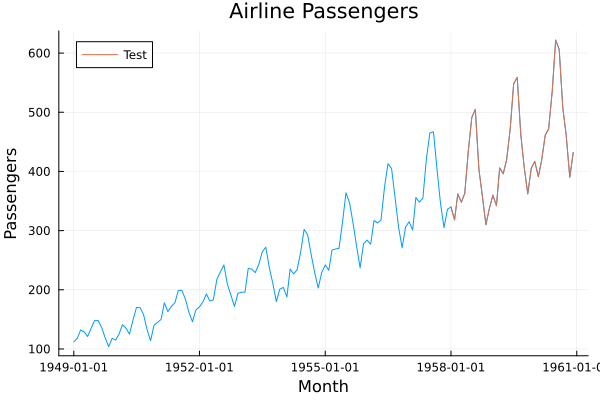

In [5]:
title = "Airline Passengers"
x_label = "Month"
y_label = "Passengers"
test_length_airline = 12*3
p_airline = plot_time_series(airline, "month", "passengers", title, x_label, y_label; test_length = test_length_airline)
display(p_airline)
savefig("output/airline.png");

When you plot the original series, you’ll notice that the seasonal ups and downs get *bigger* over time. This means the variance of the seasonal component isn’t constant — it grows over time. That’s a problem for many models that assume the variance is stable (a.k.a. *homoscedastic*). 

To deal with this, we apply a simple but powerful trick: **log-transform the data**. Taking the logarithm helps **stabilize the unconditional variance**, which makes it easier for our models to learn the structure of the series — especially the seasonal part. If, however, we have evidence of **conditional heterochedasticity**, the log itself is not sufficient to handle it.

Here’s how we load and log-transform the dataset and plot the transformed series. See how the ups and downs seems to have the same amplitude over time?

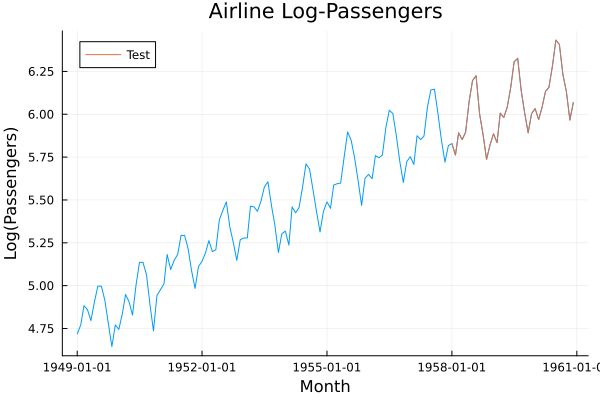

In [6]:
log_airline = deepcopy(airline);
log_airline.passengers = log.(log_airline.passengers);

title = "Airline Log-Passengers"
x_label = "Month"
y_label = "Log(Passengers)"
test_length_airline = 12*3
p_logairline = plot_time_series(log_airline, "month", "passengers", title, x_label, y_label; test_length = test_length_airline)
display(p_logairline)
savefig("output/airline_log.png");

## Train-test split

As in any good machine learning workflow, we shouldn’t train our model on all the data and then judge its performance on the same data. That’s cheating.

To really know how well our model is doing, we need to test it on data it hasn’t seen before — data that wasn’t used during estimation. That’s why we split our dataset into two parts:

- a **training set**, to fit the model,
- and a **test set**, to evaluate its forecasting accuracy.

In time series, this split has to respect the order of the data — no shuffling allowed! We simply cut the last `N` observations to serve as our test set and keep the rest for training.

In [7]:
airline_train, airline_test = time_series_split(log_airline, test_length_airline);

## A quick dive into structural time series models

At the heart of `StateSpaceModels.jl` is the **state space representation** of time series models — a flexible way to write models that evolve over time. Some classic time series models, such as the ARIMA family and Exponential Smoothing (ETS) family can be written in this form. The state space framework and the Kalman Filter as strongly related, but this is a topic for another time.

I will only define the state space form of any given model as:

$$
\begin{align*}
y_t &= Z_t\alpha_t + d_t +\varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, \sigma^2_\varepsilon)\\
\alpha_{t+1} &= T_t\alpha_t + c_t + R_t\eta_t \quad \eta_t \sim \mathcal{N}(0, \sigma^2_\eta)
\end{align*}
$$

One particularly useful class is the **structural time series models**, where we explicitly model components like **trend**, **seasonality**, **cycles**, and **noise**.

The general form of a structural model is:

$$
y_t = \mu_t + \gamma_t + c_t + \varepsilon_t
$$

Here:

-  $y_t$ is the observed value at time  $t$,
-  $\mu_t$ is the **trend or level** component,
-  $\gamma_t$ is the **seasonal** component,
-  $c_t$ is the **cycle** (we won’t use it in this tutorial),
-  $\varepsilon_t$ is the **irregular noise**.

This is called the **observation equation** — it links the hidden structure of the model to the actual data we observe.

Each of the components evolves over time according to its own **state equation**. For example, the **Basic Structural Model** (BSM), which we'll use a lot here, is made of:

### Basic Structural Model equations

$$
\begin{align*}
y_t &= \mu_t + \gamma_t + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, \sigma^2_\varepsilon)\\
\mu_{t+1} &= \mu_t + \nu_t + \xi_t, \quad \xi_t \sim \mathcal{N}(0, \sigma^2_\xi)\\
\nu_{t+1} &= \nu_t + \zeta_t, \quad \zeta_t \sim \mathcal{N}(0, \sigma^2_\zeta)\\
\gamma_t &= -\sum_{j=1}^{s-1} \gamma_{t-j} + \omega_t, \quad \omega_t \sim \mathcal{N}(0, \sigma^2_\omega)
\end{align*}
$$

#### Observation equation:
$$
y_t = \mu_t + \gamma_t + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, \sigma^2_\varepsilon)
$$

#### State equations:
- Trend (local linear trend):
  $$
  \mu_{t+1} = \mu_t + \nu_t + \xi_t, \quad \xi_t \sim \mathcal{N}(0, \sigma^2_\xi)
  $$
  $$
  \nu_{t+1} = \nu_t + \zeta_t, \quad \zeta_t \sim \mathcal{N}(0, \sigma^2_\zeta)
  $$

- Seasonality (stochastic):
  $$
  \gamma_t = -\sum_{j=1}^{s-1} \gamma_{t-j} + \omega_t, \quad \omega_t \sim \mathcal{N}(0, \sigma^2_\omega)
  $$




This setup allows each component to evolve in time with its own randomness — making the model highly interpretable and very flexible.

## Models available in StateSpaceModels.jl

The package supports several types of models that can all be written in **state space form**, including: SARIMA, ETS, DAR, BasicStructual, BasicStructuralExplanatory, LinearRegression and some naive models as well (naive and seasonal naive).

We’ll mostly focus on the `BasicStructural` model here — but once you get the hang of it, switching to other types is straightforward.


## Specifying the models

In [8]:
ssm_airline = StateSpaceModels.UnobservedComponents(airline_train.passengers;
                                                    trend = "local linear trend",
                                                    seasonal = "stochastic 12",
                                                    cycle = "no");
# It would be equivalent to:
# ssm_airline = StateSpaceModels.BasicStructural(airline_train.passengers, 12);

UnobservedComponents

## Fitting the models

Once we've defined our model, fitting it is super straightforward. The `fit!` function takes care of estimating the parameters using maximum likelihood - namely, the variances of the components: irregular, trend, slope, and seasonal.

If any of these variances are estimated as zero, it means the corresponding component is deterministic, not stochastic. In other words, the model believes that component doesn't need randomness to explain the data.


This shows us the estimated variances, standard errors, and p-values for each component. In the output below, we can see that both the slope and seasonal variances were estimated as zero. At first glance, this suggests these components might be deterministic. But let's not rush - we should always look at the p-values.

The p-values associated with the irregular, trend and seasonality variances are all smaller than 0.01, which means that the null-hypothesis of each t-test (which says that the given parameter is equal to zero) is false. That being said, even though the fitted variance of the seasonal component was fitted as zero, the t-test says that we have strong evidence that it is not, so that this component is actually stochastic. The slope component, on the other hand, seems deterministic, since the p-value from the t-test is 1, which means that we do not have evidence to conclude that it's value is not zero.estiamted as zero, indicating (at a first glance) a deterministic component. However, one should investigate the p-value of the X statistic (write the conclusion for pvalues 1 and 0.0018).

In [9]:
StateSpaceModels.fit!(ssm_airline);

┌ Warning: f_tol is deprecated. Use f_abstol or f_reltol instead. The provided value (1.0e-6) will be used as f_reltol.
└ @ Optim /home/mathnog/.julia/packages/Optim/7krni/src/types.jl:120


In [10]:
printstyled("Airline Passengers Model Results\n", color = :green)
print_results(ssm_airline);

Airline Passengers Model Results
                             Results                           
Model:                        UnobservedComponents
Number of observations:       108
Number of unknown parameters: 4
Log-likelihood:               171.2789
AIC:                          -334.5577
AICc:                         -334.1694
BIC:                          -323.8292
----------------------------------------------------------------------
Parameter             Estimate      Std.Error      z stat      p-value
sigma2_irregular        0.0003         0.0052      0.0492       0.0000
sigma2_trend            0.0006         0.0046      0.1332       0.0000
sigma2_slope            0.0000         0.0007      0.0000       1.0000
sigma2_seasonal         0.0000         0.0028      0.0089       0.0018


## Diagnostics

A crucial step after fitting any model is to check the residuals - and in the state space framework, we do this by analyzing the standardized innovations.
These innovations are the fitted values of the error terms - especially the one from the observation equation. In other words, they represent what the model couldn't explain, scaled by the uncertainty at each point.

To get them, we run the Kalman filter and extract the innovations:


In [11]:
filter_airline = StateSpaceModels.kalman_filter(ssm_airline)
std_inov = StateSpaceModels.get_standard_innovations(filter_airline);
std_residuals = StateSpaceModels.get_standard_residuals(filter_airline);


The BSM model (and most state space models) assumes that the residuals are: uncorrelated over time and normally distributed (i.e., errors are Gaussian white noise).
We can easily check these assumptions with:

This will give us:
 - A time series plot of the residuals,
 - The autocorrelation function (ACF),
 - A histogram to check symmetry and outliers,
 - A Q-Q plot to visually assess normality

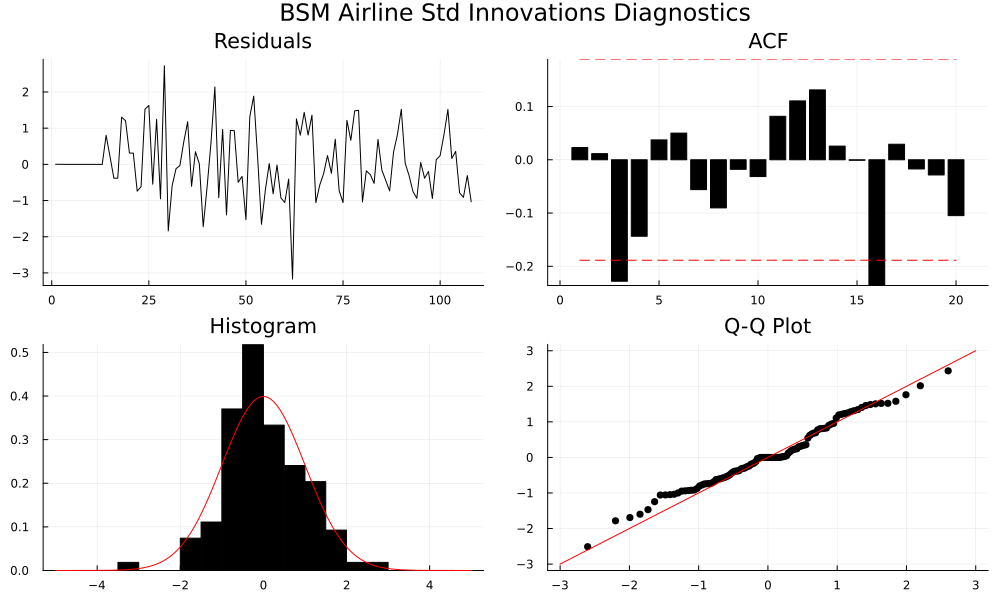

"/home/mathnog/Documents/Medium/MathNogMediumArticles/TimeSeriesJulia/StateSpaceModels/output/airline_bsm_diagnostics.png"

In [12]:
p_diag = StateSpaceModels.plotdiagnostics(kalman_filter(ssm_airline), size = (1000, 600), 
                                        plot_title = "BSM Airline Std Innovations Diagnostics",
                                        title = ["Residuals" "ACF" "Histogram" "Q-Q Plot"])
display(p_diag)
savefig("output/airline_bsm_diagnostics.png")

In [13]:
plot(airline_train.month, std_inov, title = "Standardized Innovations", label = "", xlabel = "Month", ylabel = "Standardized Innovations")
savefig("output/airline_bsm_innovations.png")

"/home/mathnog/Documents/Medium/MathNogMediumArticles/TimeSeriesJulia/StateSpaceModels/output/airline_bsm_innovations.png"

In [14]:
plot(airline_train.month, std_residuals, title = "Standardized Residuals", label = "", xlabel = "Month", ylabel = "Standardized Residuals")
savefig("output/airline_bsm_residuals.png")

"/home/mathnog/Documents/Medium/MathNogMediumArticles/TimeSeriesJulia/StateSpaceModels/output/airline_bsm_residuals.png"

## Getting the predictive, filtered and smoothed states

One of the best things about using structural state space models is that we don’t just get a black-box prediction — we actually **see the inner structure** of the time series.

In particular, we can access the **latent states** estimated by the Kalman filter, which give us the values (and uncertainty) of each hidden component: trend, slope, seasonality, etc.

But first: what exactly is a *state*?

In this context, the **state** is the collection of unobserved variables that drive the dynamics of the series. For the Basic Structural Model, that includes the level, slope, and seasonal effects.

We can estimate these states in three different ways:

- **Predictive states**  
  Estimated before seeing the current data point:  
  $$ a_{t|t-1} = \mathbb{E}[\alpha_t \mid y_{1:t-1}] $$

- **Filtered states**  
  Estimated *after* seeing the current data point:  
  $$ a_{t|t} = \mathbb{E}[\alpha_t \mid y_{1:t}] $$

- **Smoothed states**  
  Estimated using *all* the data (past and future):  
  $$ a_{t|T} = \mathbb{E}[\alpha_t \mid y_{1:T}] $$

You can get each one with:
<!-- $$
\begin{align*}
  \text{Predictive State: }&a_{t|t-1} = \mathbb{E}[\alpha_t \mid y_{1:t-1}]\\
  \text{Filtered State: }&a_{t|t} = \mathbb{E}[\alpha_t \mid y_{1:t}]\\
  \text{Smoothed State: }&a_{t|T} = \mathbb{E}[\alpha_t \mid y_{1:T}]
  \end{align*}
$$ -->

In [15]:
predictive_states = StateSpaceModels.get_predictive_state(ssm_airline);
filtered_states   = StateSpaceModels.get_filtered_state(ssm_airline);
smoothed_states   = StateSpaceModels.get_smoothed_state(ssm_airline);

From the estimated states, we can extract the actual time series components - like the smoothed trend, filtered slope, or predictive seasonality:

In [16]:
smoothed_level, smoothed_slope, smoothed_seasonality       = get_components_from_states(smoothed_states);
filtered_level, filtered_slope, filtered_seasonality       = get_components_from_states(filtered_states);
predictive_level, predictive_slope, predictive_seasonality = get_components_from_states(predictive_states);

Why is this important?

Because now we can study the time series itself, not just predict it with a black-box model (yes, neural networks, I am talking to you).

Using the filtered and smoothed components, we can answer questions like:

 - How did the trend evolve over time?
 - Was there a sudden shift in growth?
 - Did seasonality change or stay stable?
 - When did the series deviate from its usual behavior?

These insights are especially useful in fields like economics, energy, retail, or any context where understanding the structure is as important as forecasting the future.

There is a built-in method to plot the smoothed components, which can be used as follows:

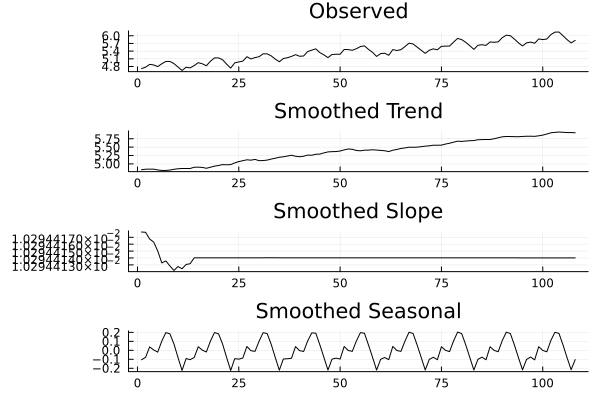

"/home/mathnog/Documents/Medium/MathNogMediumArticles/TimeSeriesJulia/StateSpaceModels/output/airline_smoothed_components.png"

In [17]:
ks = StateSpaceModels.kalman_smoother(ssm_airline)
comp_smooth = plot(ssm_airline, ks)
display(comp_smooth)
savefig("output/airline_smoothed_components.png")

If we want to see the other components, we should do it by hand, as it is done below.

A curious mind may be asking itself why the initial values from the slope component seems unstable. This usually happens with models fitted with the Kalman filter, which needs the first observations to "warm up". This is so common that in the following functions, I have chosen to exclude the first 12 observations from all components. This is not cheating if you know what you are doing!

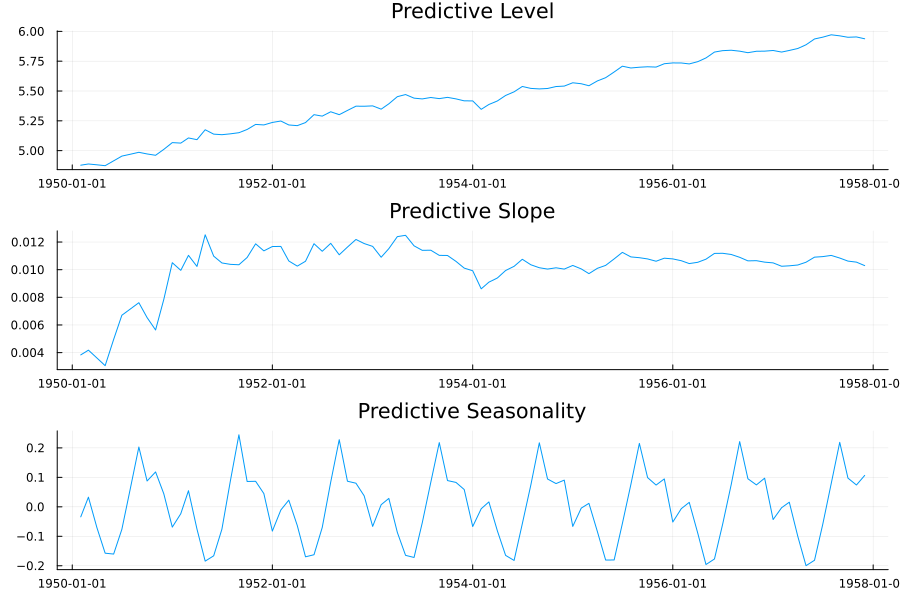

"/home/mathnog/Documents/Medium/MathNogMediumArticles/TimeSeriesJulia/StateSpaceModels/output/predictive.png"

In [18]:
p_predictive = plot_components(airline_train.month, predictive_level, predictive_slope, predictive_seasonality, "Predictive")
display(p_predictive)
savefig(p_predictive, "output/predictive.png")

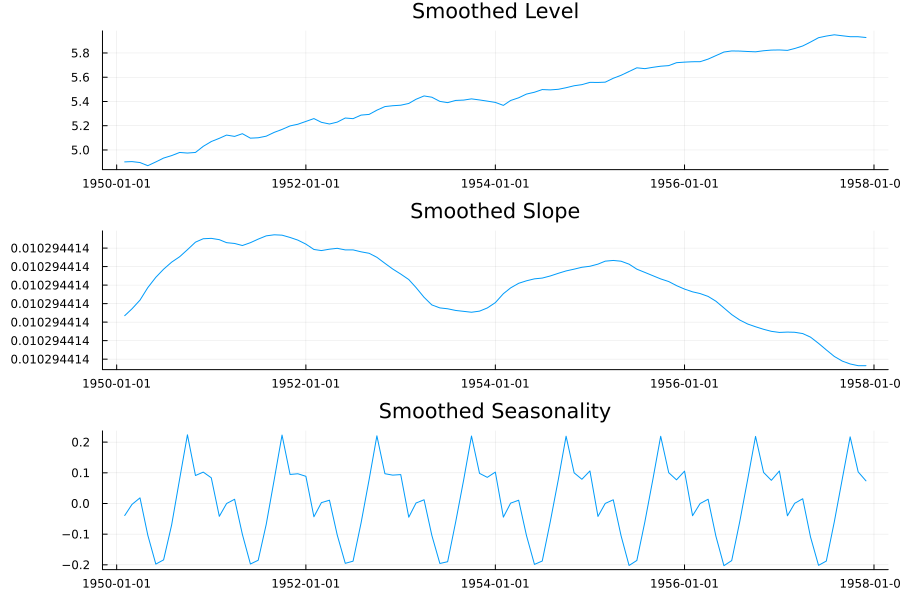

"/home/mathnog/Documents/Medium/MathNogMediumArticles/TimeSeriesJulia/StateSpaceModels/output/smoothed.png"

In [19]:
plot_smoothed = plot_components(airline_train.month, smoothed_level, smoothed_slope, smoothed_seasonality, "Smoothed")
display(plot_smoothed)
savefig(plot_smoothed, "output/smoothed.png")

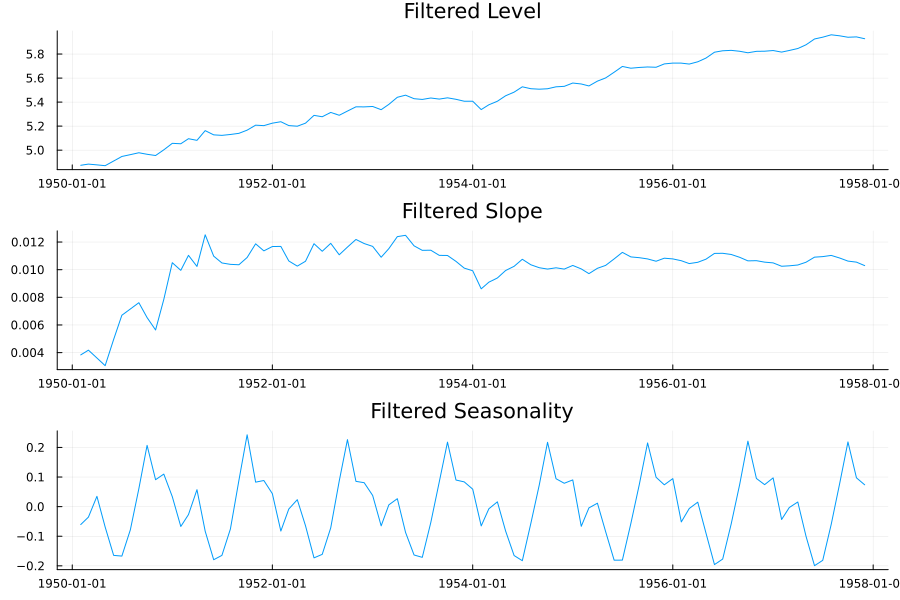

"/home/mathnog/Documents/Medium/MathNogMediumArticles/TimeSeriesJulia/StateSpaceModels/output/filtered.png"

In [20]:
p_filtered = plot_components(airline_train.month, filtered_level, filtered_slope, filtered_seasonality, "Filtered")
display(p_filtered)
savefig(p_filtered, "output/filtered.png")

It would be important to guarantee that the output we saw earlier, with the fitted variances, correspond to nature of the plotted components. Since the fitted BSM is a predictive model, we must analyse the predictive components. As expected, the trend and seasonal components are stochastic - they change over time - while the slope is deterministic and, in this case, constant!

## Out of sample forecast and simulation

Alright, now for the main event 🥁 

As a forecaster guy™, this is where things get exciting: how do we make forecasts from a fitted state space model?

Not just point forecasts - we also want probabilistic scenarios, because in real life, we care about uncertainty too.

Luckily, StateSpaceModels.jl makes this super easy. You only need three functions:

Checar exatamente o que cada funcao faz

- `forecast`: gives you the distribution of the future states.
- `simulate_scenarios`: samples possible future paths (Monte Carlo-style).
- `forecast_expected_value`: gives you the expected value (mean) of the forecast.

Let's run them:

In [21]:
S = 1000
scenarios_airline      = simulate_scenarios(ssm_airline, test_length_airline, S);
forecast_airline       = forecast(ssm_airline, test_length_airline);
expected_value_airline = forecast_expected_value(forecast_airline);

Now you have:
 - forecast_airline: full probabilistic forecast object (including variances).
 - scenarios_airline: a bunch of random paths your series might follow.
 - expected_value_airline: the most likely forecast path (mean prediction).

This is where structural models shine: they don't just spit out a number - they give you a full distribution, respecting all the structure you've captured (trend, seasonality, uncertainty, etc.).

Next up, let's visualize those forecasts and compare them to the actual test data with the following function (available in my github)

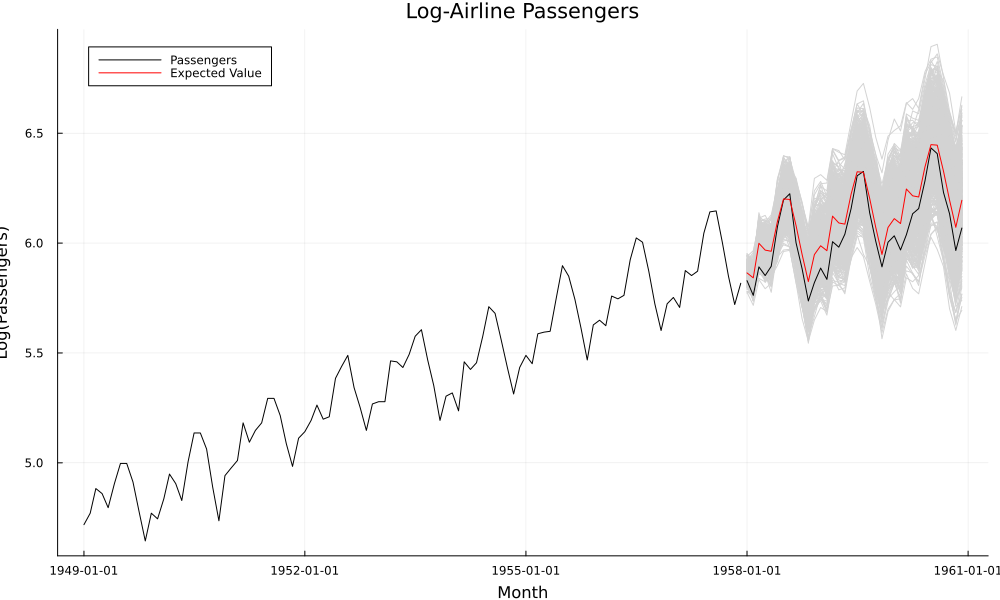

"/home/mathnog/Documents/Medium/MathNogMediumArticles/TimeSeriesJulia/StateSpaceModels/output/airline_forecast.png"

In [22]:
title = "Log-Airline Passengers"
x_axis = "month"
y_axis = "passengers"
x_label = "Month"
y_label = "Log(Passengers)"

p_forecast = plot_forecast(airline_train, airline_test, vec(expected_value_airline), scenarios_airline[:, 1, :], title, x_axis, y_axis, x_label, y_label);
display(p_forecast)
savefig(p_forecast, "output/airline_forecast.png")

## Model Comparison

Lets fit 2 automatic forecasting models, but with some help: let's, at least, tell the models that our time series is seasonal! 

This help will make the heuristic that finds the best model way more accurate.

In [23]:
auto_arima_airline = StateSpaceModels.auto_arima(airline_train.passengers; seasonal = 12);
auto_ets_airline   = StateSpaceModels.auto_ets(airline_train.passengers; seasonal = 12);

┌ Warning: f_tol is deprecated. Use f_abstol or f_reltol instead. The provided value (1.0e-6) will be used as f_reltol.
└ @ Optim /home/mathnog/.julia/packages/Optim/7krni/src/types.jl:120
┌ Error: Numerical error when applying Kalman filter equations.
└ @ StateSpaceModels /home/mathnog/.julia/packages/StateSpaceModels/WqsHx/src/filters/univariate_kalman_filter.jl:330
┌ Warning: f_tol is deprecated. Use f_abstol or f_reltol instead. The provided value (1.0e-6) will be used as f_reltol.
└ @ Optim /home/mathnog/.julia/packages/Optim/7krni/src/types.jl:120
┌ Error: Numerical error when applying Kalman filter equations.
└ @ StateSpaceModels /home/mathnog/.julia/packages/StateSpaceModels/WqsHx/src/filters/univariate_kalman_filter.jl:330
┌ Warning: f_tol is deprecated. Use f_abstol or f_reltol instead. The provided value (1.0e-6) will be used as f_reltol.
└ @ Optim /home/mathnog/.julia/packages/Optim/7krni/src/types.jl:120
┌ Warning: f_tol is deprecated. Use f_abstol or f_reltol instead. The

Now, we can compute the expected value and the scenarios for both models.

In [24]:
scenarios_arima_airline       = simulate_scenarios(auto_arima_airline, test_length_airline, S);
expected_value_arima_airline  = forecast_expected_value(forecast(auto_arima_airline, test_length_airline));

scenarios_ets_airline        = simulate_scenarios(auto_ets_airline, test_length_airline, S);
expected_value_ets_airline   = forecast_expected_value(forecast(auto_ets_airline, test_length_airline));

And, also, compute the mean MAE and CRPS across all 26 steps ahead from the forecast horizon.

In [25]:
mean_bsm_crps = mean(StateSpaceModels.evaluate_crps(airline_test.passengers, scenarios_airline[:, 1, :]));
mean_bsm_mae  = mean(StateSpaceModels.evaluate_abs_error(airline_test.passengers, vec(expected_value_airline)));

mean_arima_crps = mean(StateSpaceModels.evaluate_crps(airline_test.passengers, scenarios_arima_airline[:, 1, :]));
mean_arima_mae  = mean(StateSpaceModels.evaluate_abs_error(airline_test.passengers, vec(expected_value_arima_airline)));

mean_ets_crps = mean(StateSpaceModels.evaluate_crps(airline_test.passengers, scenarios_ets_airline[:, 1, :]));
mean_ets_mae  = mean(StateSpaceModels.evaluate_abs_error(airline_test.passengers, vec(expected_value_ets_airline)));

DataFrame(
    Model = ["BSM", "ARIMA", "ETS"],
    CRPS = [mean_bsm_crps, mean_arima_crps, mean_ets_crps],
    MAE = [mean_bsm_mae, mean_arima_mae, mean_ets_mae]
)

Row,Model,CRPS,MAE
,String,Float64,Float64
1,BSM,0.0515208,0.0753921
2,ARIMA,0.0460893,0.0564732
3,ETS,0.0539861,0.0770458


## Cross Validation

Let's wrap things up with a super useful tool: cross-validation.

If you come from machine learning, you probably know this idea already - we split the data into multiple training and testing segments, fit the model on each training chunk, and evaluate how well it performs on the corresponding test chunk.

But in time series, we can't just randomly shuffle data around. Time matters.
That's why we use rolling or expanding window cross-validation. We train the model on a moving window of past data, then test it on a fixed-size future window. Repeat this several times and average the results.

This gives you a much more robust estimate of forecasting performance - especially when your series changes over time.

In StateSpaceModels.jl, it's as easy as:

In [26]:
start_idx = 50
cv = StateSpaceModels.cross_validation(ssm_airline, test_length_airline, start_idx);

CrossValidation: step 1 of 22


┌ Warning: f_tol is deprecated. Use f_abstol or f_reltol instead. The provided value (1.0e-6) will be used as f_reltol.
└ @ Optim /home/mathnog/.julia/packages/Optim/7krni/src/types.jl:120


CrossValidation: step 2 of 22
CrossValidation: step 3 of 22
CrossValidation: step 4 of 22
CrossValidation: step 5 of 22
CrossValidation: step 6 of 22
CrossValidation: step 7 of 22
CrossValidation: step 8 of 22
CrossValidation: step 9 of 22
CrossValidation: step 10 of 22
CrossValidation: step 11 of 22
CrossValidation: step 12 of 22
CrossValidation: step 13 of 22
CrossValidation: step 14 of 22
CrossValidation: step 15 of 22
CrossValidation: step 16 of 22
CrossValidation: step 17 of 22
CrossValidation: step 18 of 22
CrossValidation: step 19 of 22
CrossValidation: step 20 of 22
CrossValidation: step 21 of 22
CrossValidation: step 22 of 22


where start_idx represents the first observation of the first window to fit the model.

This function returns mean MAE and CRPS metrics from all windows by step ahead. This is an interesting plot because it enables us to see how the model forecast performance evolve along the forecast horizon. As we can see above, the forecast accuracy decreases over time. Fair enought! Further in the future, more difficult to foreacst!

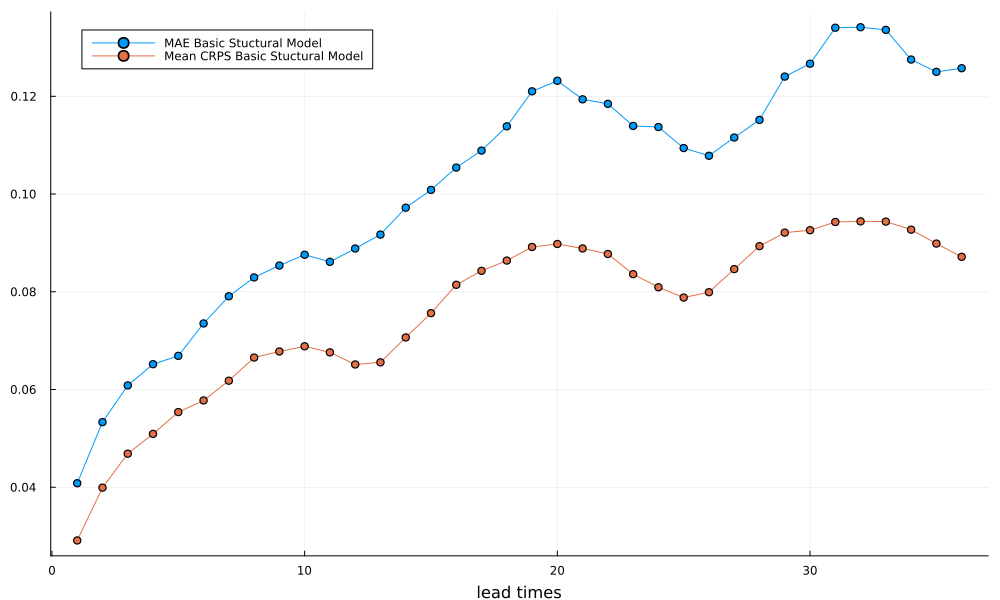

In [27]:
plot_cv = plot(cv, "Basic Stuctural Model", size = (1000, 600))
display(plot_cv)
savefig("output/airline_cv.png");